In [2]:
# 安装依赖
#!pip install sentence-transformers pandas scikit-learn matplotlib

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# 示例数据集（新闻标题）
articles = [
    "Apple unveils new iPhone with advanced AI camera",
    "Google announces breakthrough in quantum computing",
    "Microsoft acquires robotics startup for $5 billion",
    "Apple stock surges after record quarterly earnings",
    "Google launches new privacy-focused search algorithm",
    "Amazon invests $10B in renewable energy projects"
]
df = pd.DataFrame({"text": articles})

/Users/zhengxin/CODES/LLM/book_ai_agent_2024/103-sentence-transformers-test1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 加载嵌入模型（网页1、网页7）
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(df['text'].tolist(), convert_to_tensor=False)

# 输出嵌入维度示例（384维）
print(f"Embedding shape: {embeddings.shape}")  # (6, 384)

Embedding shape: (6, 384)


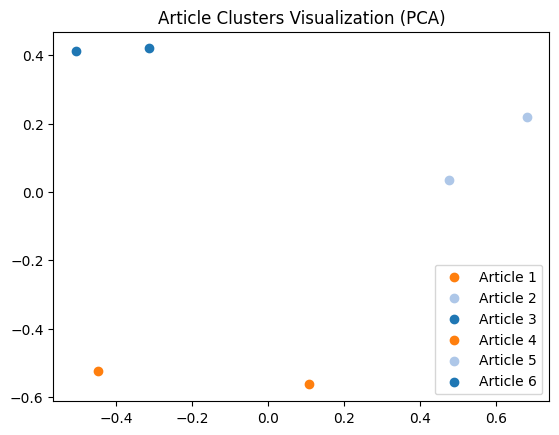

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# K-means聚类（网页1、网页3）
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# PCA降维可视化
pca = PCA(n_components=2)
vis_embeddings = pca.fit_transform(embeddings)

for i, (x, y) in enumerate(vis_embeddings):
    plt.scatter(x, y, c=[plt.cm.tab20(clusters[i])], marker='o', label=f"Article {i+1}")

plt.title("Article Clusters Visualization (PCA)")
plt.legend()
plt.show()